In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder,StandardScaler,LabelEncoder,RobustScaler

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error,r2_score,root_mean_squared_error,mean_absolute_error
from sklearn.model_selection import GridSearchCV
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score
from sklearn.cluster import DBSCAN

In [4]:
df = pd.read_csv("housing.csv")
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [5]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

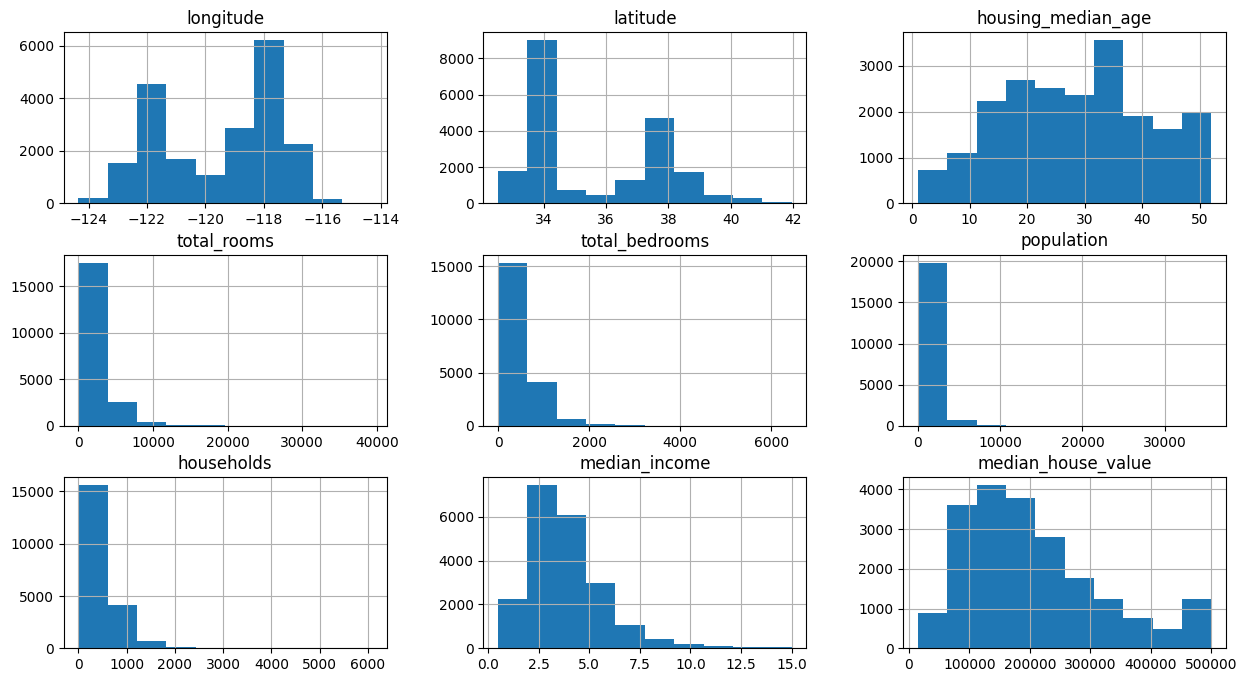

In [6]:
df.hist(figsize=(15,8))

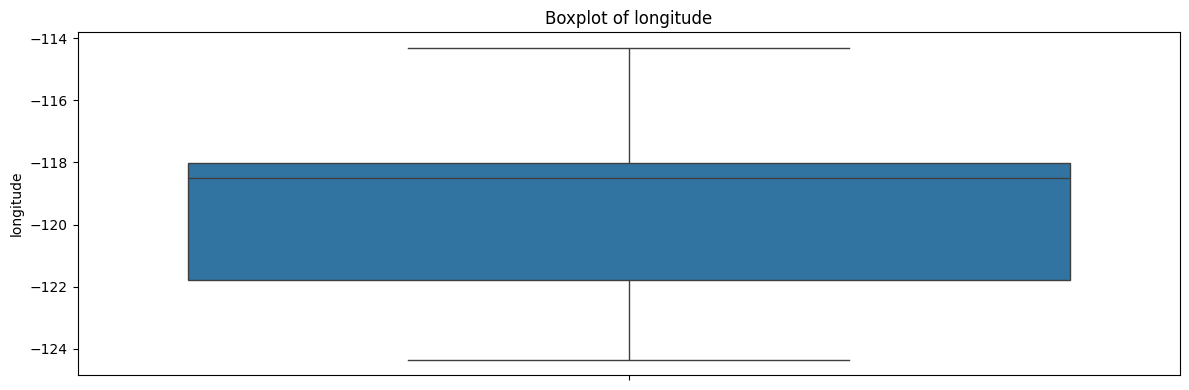

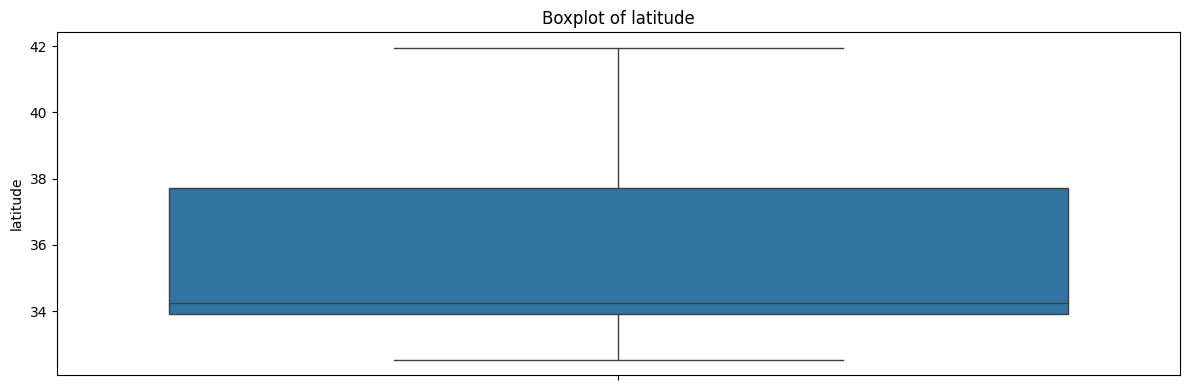

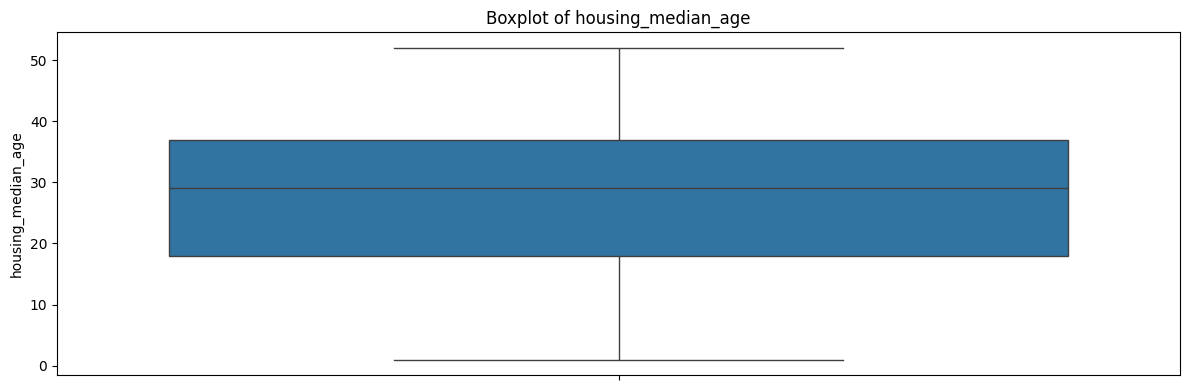

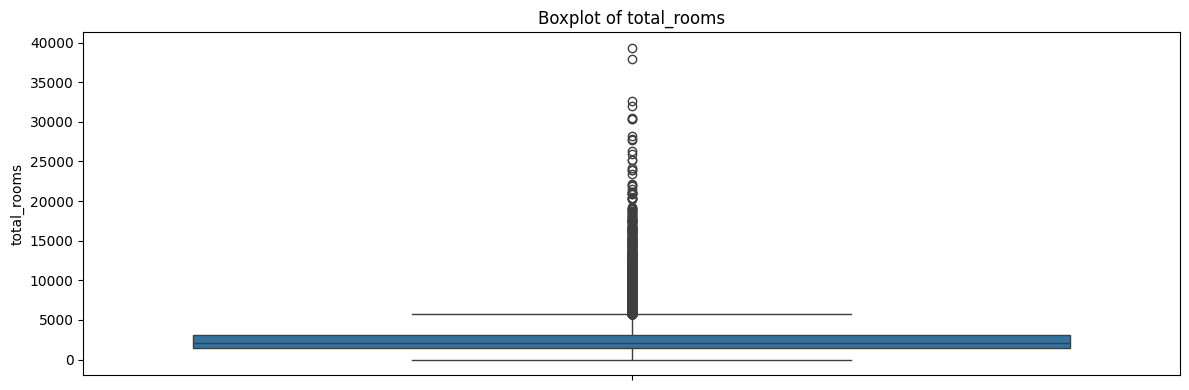

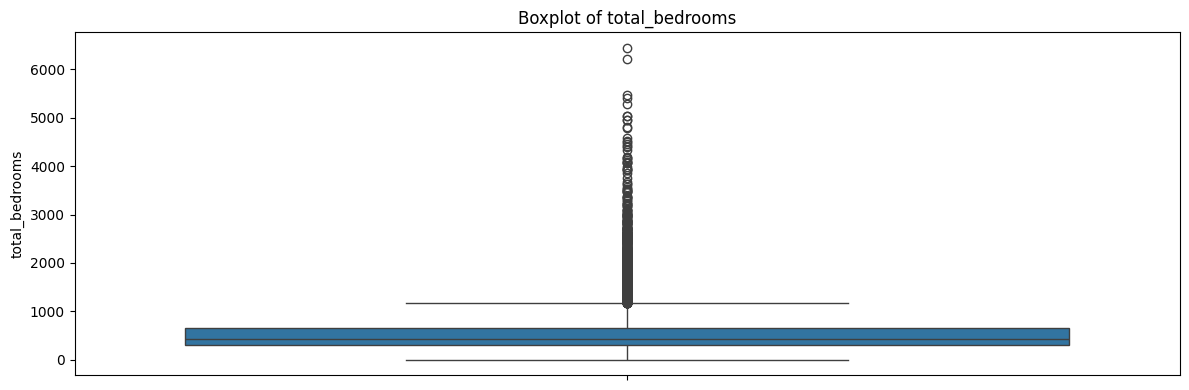

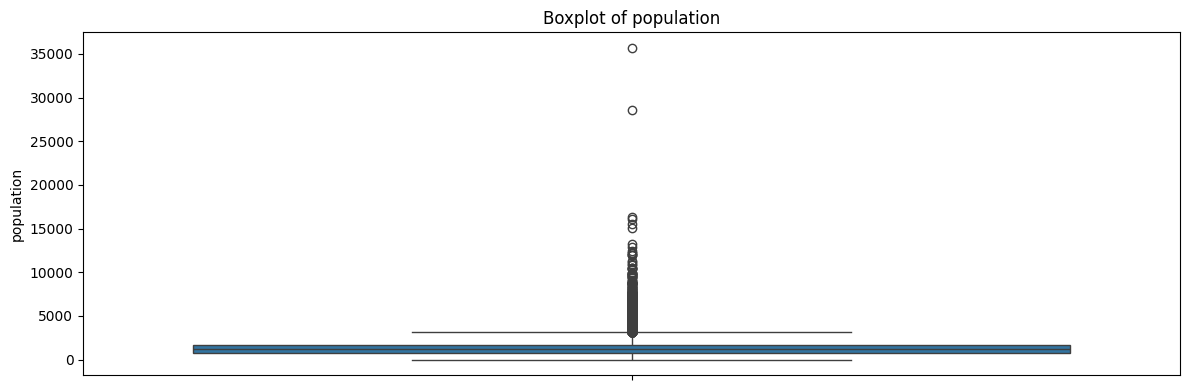

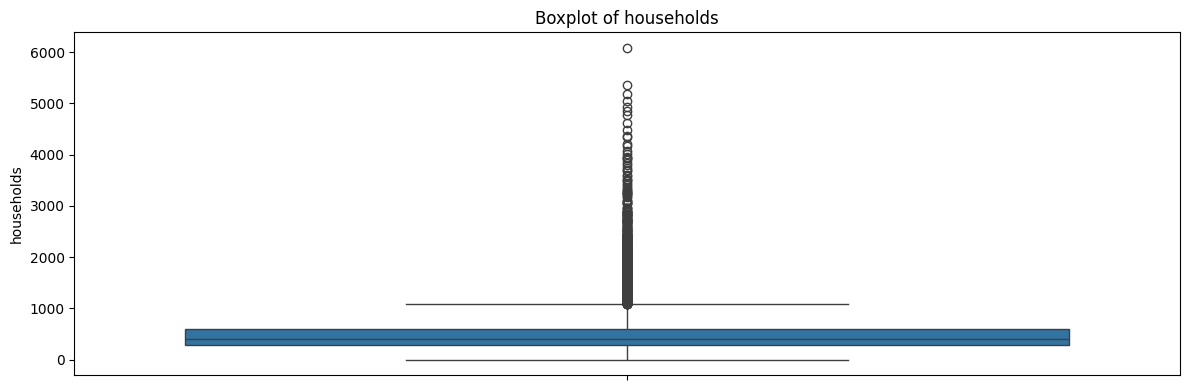

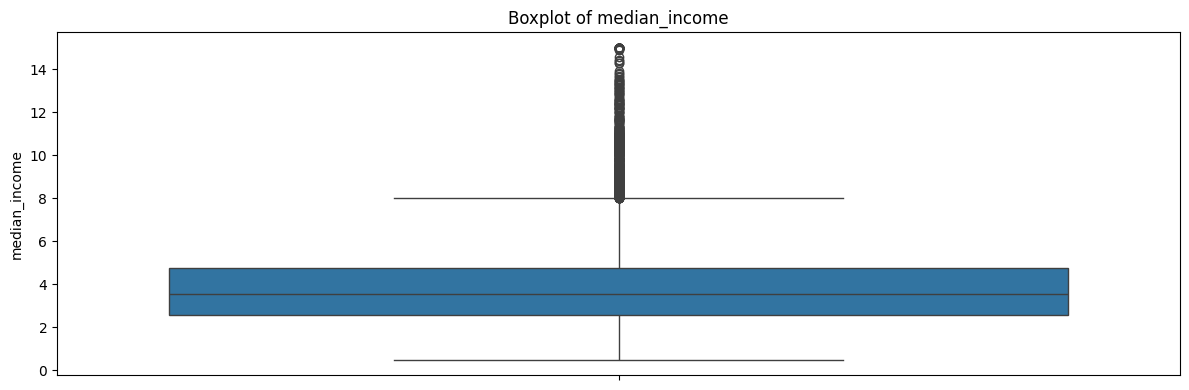

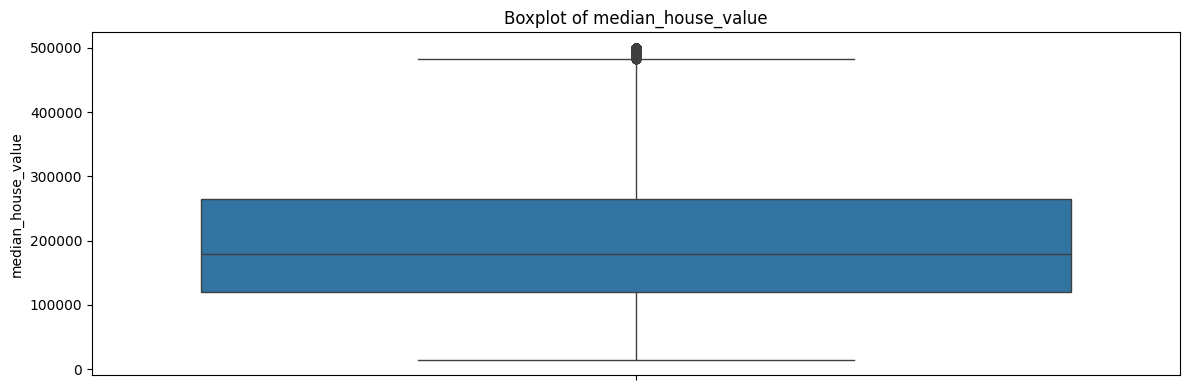

In [7]:
numeric_cols=['longitude','latitude','housing_median_age','total_rooms','total_bedrooms','population','households','median_income','median_house_value']
for col in numeric_cols:
  plt.figure(figsize=(12,4))
  sns.boxplot(y= df[col])
  plt.title(f'Boxplot of {col}')

  plt.tight_layout()
  plt.show()

<Axes: xlabel='latitude', ylabel='longitude'>

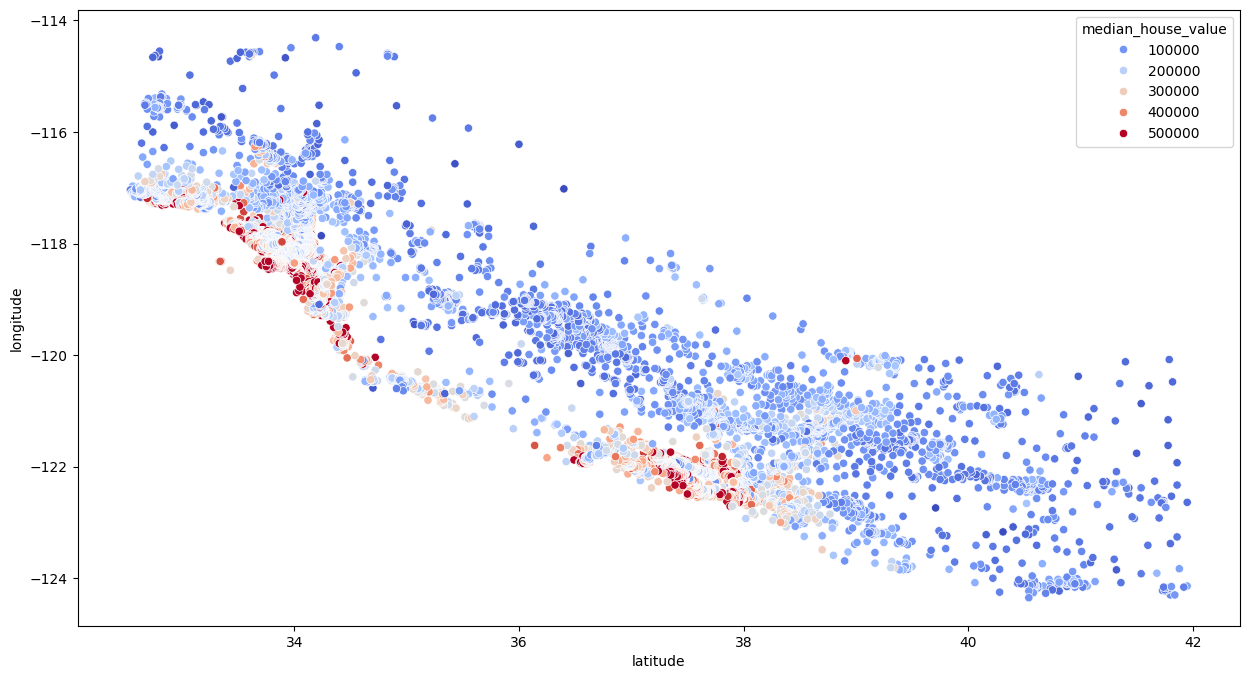

In [8]:
plt.figure(figsize=(15,8))
sns.scatterplot(x='latitude',y='longitude',data=df,hue='median_house_value',palette='coolwarm')

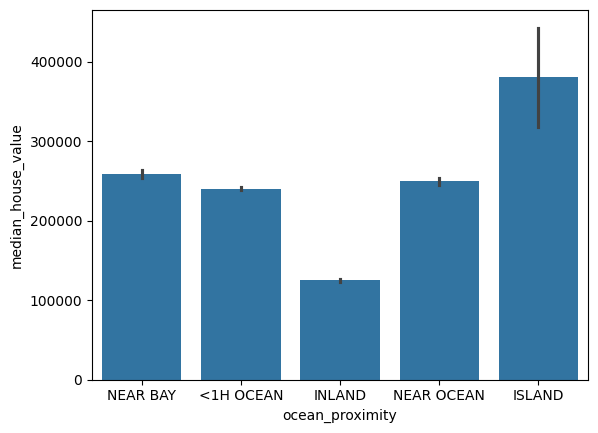

In [9]:
sns.barplot(x='ocean_proximity', y='median_house_value', data=df)
plt.show()

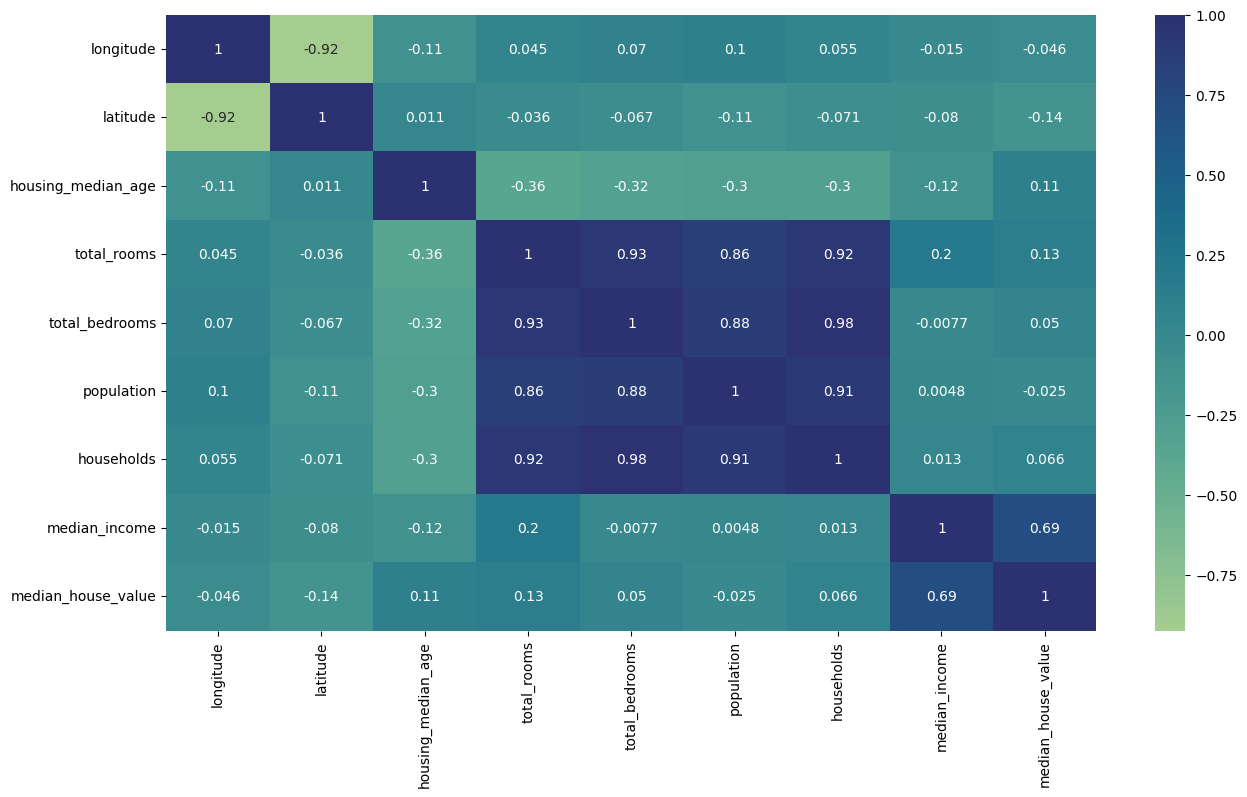

In [10]:
plt.figure(figsize=(15,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='crest')
plt.show()

In [11]:
df['household_room'] = df['total_rooms']/df['households']

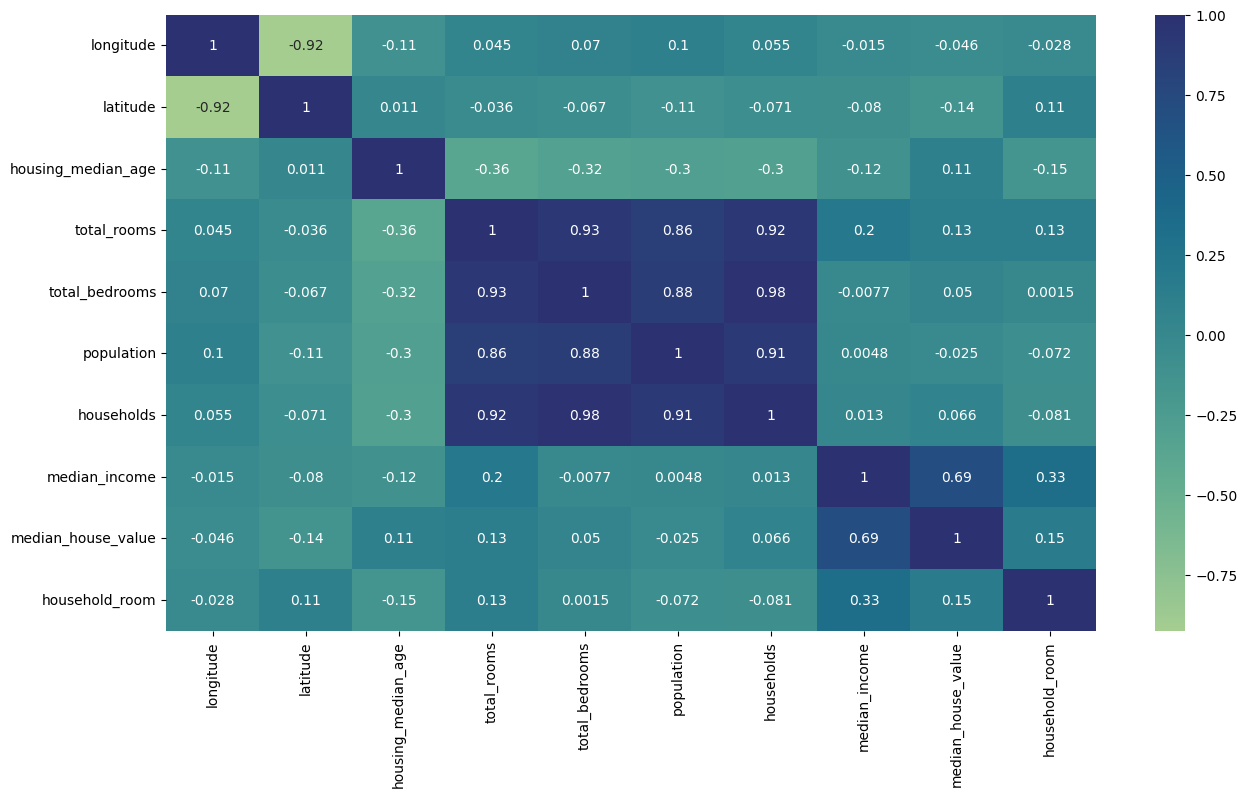

In [12]:
plt.figure(figsize=(15,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='crest')
plt.show()

In [13]:
X = df.drop('median_house_value',axis=1)
y=df['median_house_value']

## Train Test split

In [14]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

## Pipeline Creation

In [15]:
p1=Pipeline(
    steps=[
        ('imputer',SimpleImputer(strategy='median')),
        ('scaler',StandardScaler())
    ]
)
p2=Pipeline(
    steps=[
        ('imputer',SimpleImputer(strategy='median')),
        ('scaler',RobustScaler())
    ]
)
p3=Pipeline(
    steps=[
        ('imputer',SimpleImputer(strategy='most_frequent')),
        ('encoder',OneHotEncoder(sparse_output=False,drop = 'first',handle_unknown='ignore'))
    ]
)
preprocessor = ColumnTransformer(
    transformers=[
        ('pipeline_1',p1,['longitude','latitude','housing_median_age','median_income']),
        ('pipline_2',p2,['total_rooms','total_bedrooms','population','households','household_room']),
        ('pipline_3',p3,['ocean_proximity'])


    ],
    remainder = 'passthrough'
)

lr_pipeline=Pipeline(
    steps=[
        ('preprocessor',preprocessor),
        ('model' , LinearRegression())
    ]
)

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

lr_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('pipeline_1',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['longitude', 'latitude',
                                                   'housing_median_age',
                                                   'median_income']),
                                                 ('pipline_2',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   RobustScaler())]),
                                                  ['total_rooms',
                                                   'total_bedrooms',
                                                   'population', 'households',
                                                   'household_room']),
                                                 ('pipline_3',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['ocean_proximity'])])),
                ('model', LinearRegression())])

In [16]:
rf_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('pipeline_1',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['longitude', 'latitude',
                                                   'housing_median_age',
                                                   'median_income']),
                                                 ('pipline_2',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   RobustScaler())]),
                                                  ['total_rooms',
                                                   'total_bedrooms',
                                                   'population', 'households',
                                                   'household_room']),
                                                 ('pipline_3',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['ocean_proximity'])])),
                ('model', RandomForestRegressor(random_state=42))])

## Model Training

In [19]:
lr_pipeline.fit(X_train,y_train)
y_pred = lr_pipeline.predict(X_test)

grid_param={
    "model__n_estimators" : [100,150],
    "model__max_depth":[10,15],
    'model__min_samples_split':[3,5]


}

grid_search_RF = GridSearchCV(
    estimator = rf_pipeline,
    param_grid = grid_param,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    cv = 5
)

In [21]:
grid_search_RF.fit(X_train,y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('pipeline_1',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['longitude',
                                                                          'latitude',
                                                                          'housing_median_age',
                                                                          'median_income']),
                                                                        ('pipline_2',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='me...
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('encoder',
                                                                                          OneHotEncoder(drop='first',
                                                                                                        handle_unknown='ignore',
                                                                                                        sparse_output=False))]),
                                                                         ['ocean_proximity'])])),
                                       ('model',
                                        RandomForestRegressor(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [10, 15],
                         'model__min_samples_split': [3, 5],
                         'model__n_estimators': [100, 150]},
             scoring='neg_mean_squared_error')

In [22]:
print(grid_search_RF.best_params_)
y_pred_rf=grid_search_RF.predict(X_test)

{'model__max_depth': 15, 'model__min_samples_split': 3, 'model__n_estimators': 150}


## Model selection/Comparison analysis

In [23]:
print("Linear Regression")
print(f"MSE: {round(mean_squared_error(y_test, y_pred), 4)}")
print(f"R2: {round(r2_score(y_test, y_pred), 4)}")
print(f"RMSE: {round(root_mean_squared_error(y_test, y_pred), 4)}")
print(f"MAE: {round(mean_absolute_error(y_test, y_pred), 4)}")
print('\n')
print("Random forest")
print(f"MSE: {round(mean_squared_error(y_test, y_pred_rf), 4)}")
print(f"R2: {round(r2_score(y_test, y_pred_rf), 4)}")
print(f"RMSE: {round(root_mean_squared_error(y_test, y_pred_rf), 4)}")
print(f"MAE: {round(mean_absolute_error(y_test, y_pred_rf), 4)}")

Linear Regression
MSE: 4877541080.799
R2: 0.6278
RMSE: 69839.3949
MAE: 50551.749


Random forest
MSE: 2433800477.3387
R2: 0.8143
RMSE: 49333.5634
MAE: 32282.8036


## Treating the problem as Unsupervised

In [24]:
dbscan_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("dbscan", DBSCAN(
        eps=0.3,
        min_samples=3
    ))
])

dbscan_pipeline.fit(X_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('pipeline_1',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['longitude', 'latitude',
                                                   'housing_median_age',
                                                   'median_income']),
                                                 ('pipline_2',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   RobustScaler())]),
                                                  ['total_rooms',
                                                   'total_bedrooms',
                                                   'population', 'households',
                                                   'household_room']),
                                                 ('pipline_3',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['ocean_proximity'])])),
                ('dbscan', DBSCAN(eps=0.3, min_samples=3))])

In [25]:
labels = dbscan_pipeline.fit_predict(X_train)
print(labels)

unique_labels = np.unique(labels)
n_clusters = len(unique_labels[unique_labels != -1])
print("Number of clusters:", n_clusters)

n_noise = np.sum(labels == -1)

print("Number of noise points:", n_noise)

[ -1  -1  -1 ... 213  -1  -1]
Number of clusters: 274
Number of noise points: 13969
